<a href="https://colab.research.google.com/github/2303A52352/EXPLAINABLE-AI/blob/main/labexam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📂 Upload your ZIP file (e.g. archive (13).zip)


Saving archive (13).zip to archive (13) (3).zip
CSV files found: ['diabetes.csv']
✅ Dataset Loaded: diabetes.csv
Shape: (768, 9)

🧹 Missing Values Before:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Missing Values After Fill:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Normalization done using Min-Max Scaling


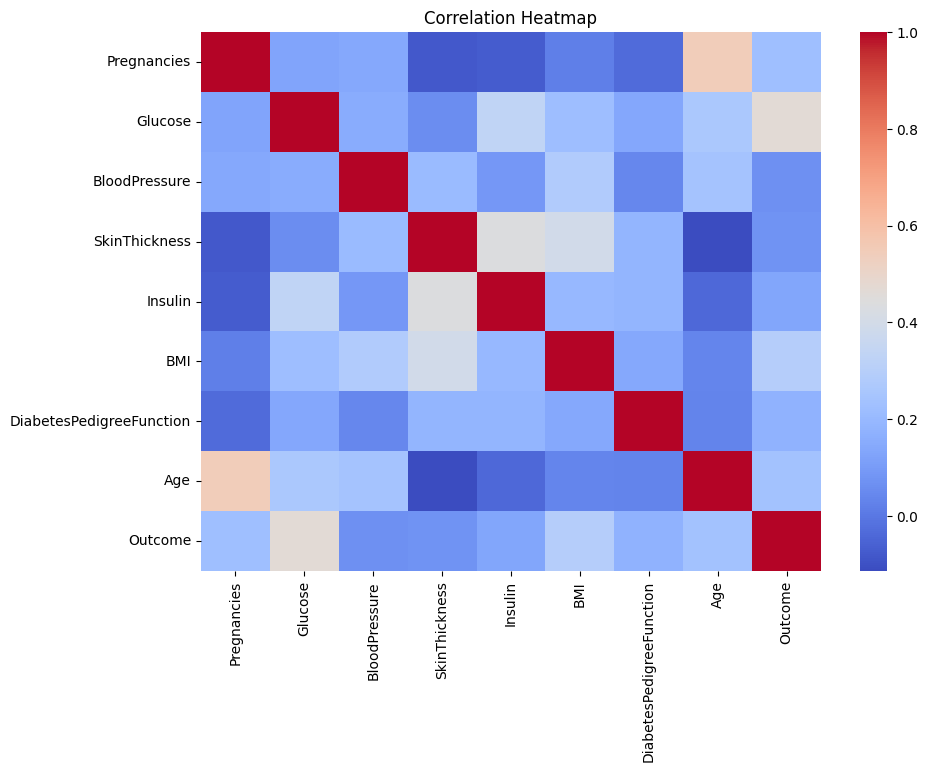

Dropped correlated features: []


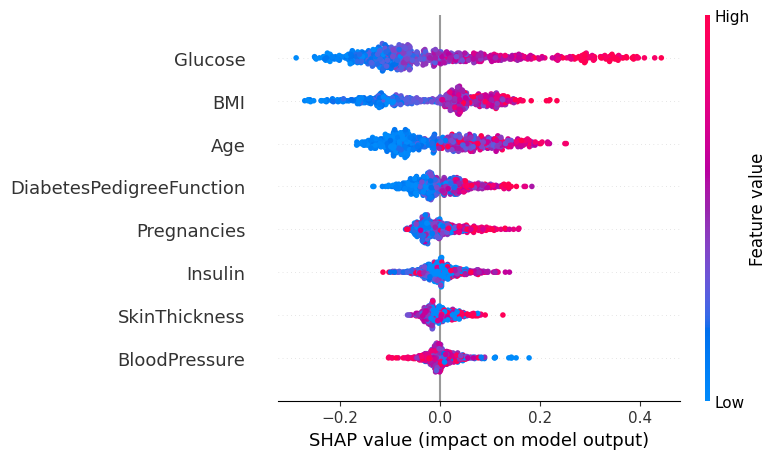

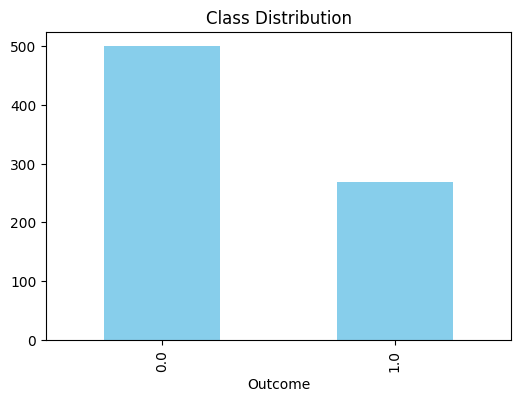

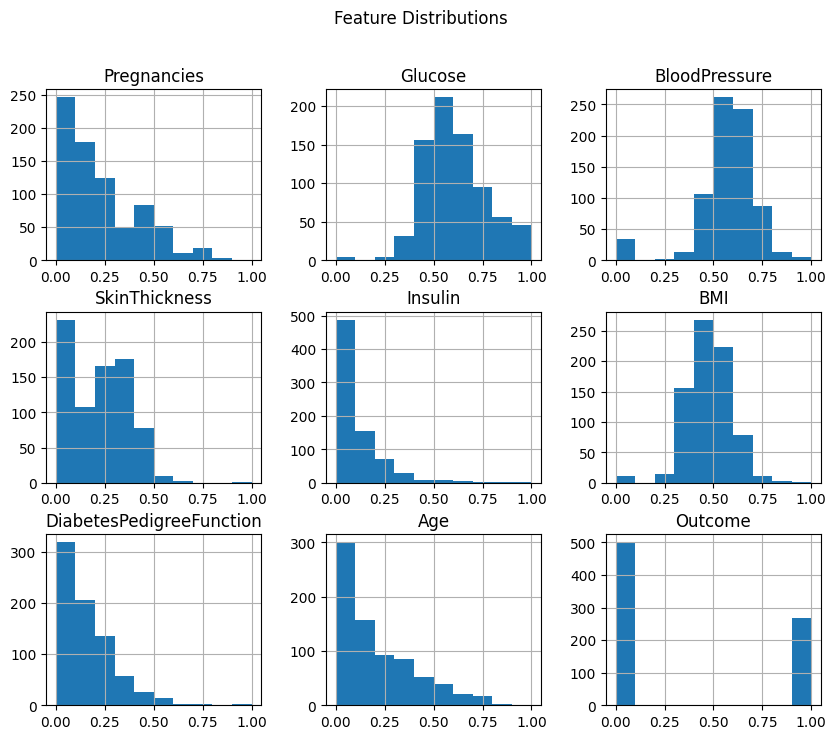

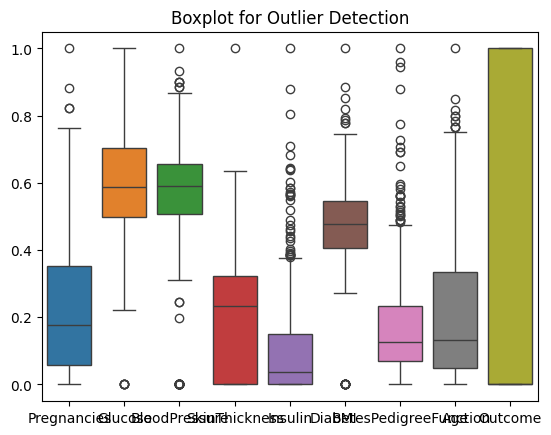


Logistic Regression → Accuracy:0.77, Precision:0.76, Recall:0.77, F1:0.76


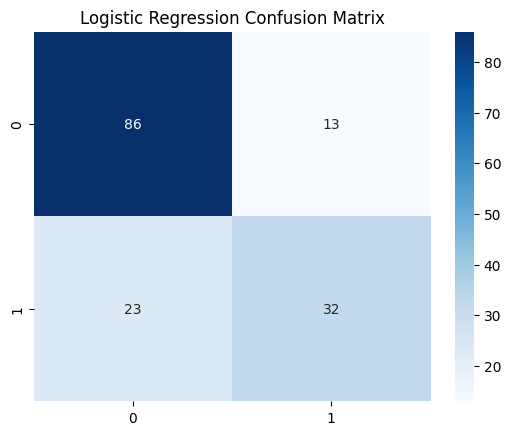


Decision Tree → Accuracy:0.77, Precision:0.77, Recall:0.77, F1:0.77


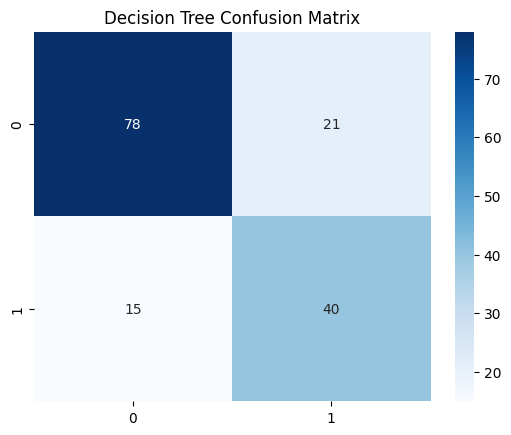


KNN → Accuracy:0.69, Precision:0.68, Recall:0.69, F1:0.68


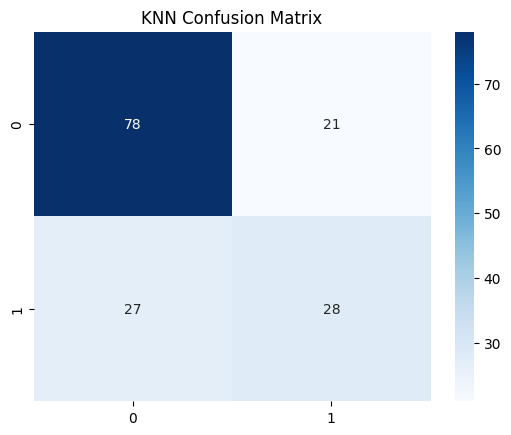


Naive Bayes → Accuracy:0.77, Precision:0.77, Recall:0.77, F1:0.77


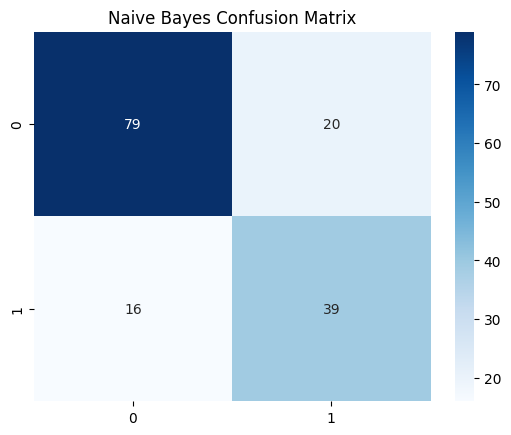


SVM → Accuracy:0.75, Precision:0.74, Recall:0.75, F1:0.74


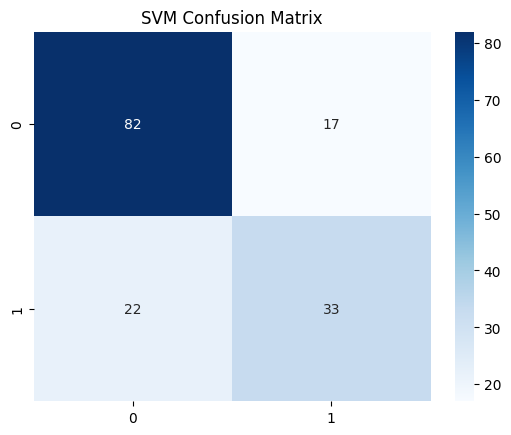

Random Forest Accuracy: 0.77
AdaBoost Accuracy: 0.78
Gradient Boosting Accuracy: 0.74
Voting Classifier Accuracy: 0.7792207792207793


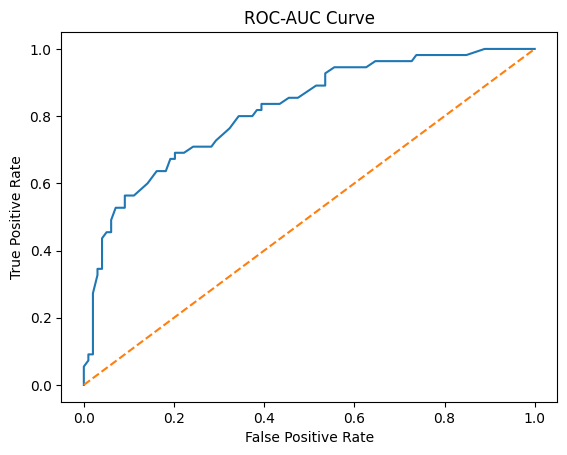

AUC Score: 0.8181818181818182


In [4]:
# ============================================
# 🔥 LAB EXAM – FULL PIPELINE IMPLEMENTATION
# ============================================

# STEP 1: IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap, zipfile, io, os, warnings
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
warnings.filterwarnings("ignore")

# ============================================
# STEP 2: UPLOAD & EXTRACT ZIP
print("📂 Upload your ZIP file (e.g. archive (13).zip)")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename]), 'r') as zip_ref:
    zip_ref.extractall("dataset")

# find the first CSV file inside the zip
csv_files = [f for f in os.listdir("dataset") if f.endswith(".csv")]
print("CSV files found:", csv_files)
csv_path = os.path.join("dataset", csv_files[0])

# Load dataset
df = pd.read_csv(csv_path)
print("✅ Dataset Loaded:", csv_files[0])
print("Shape:", df.shape)
df.head()

# ============================================
# STEP 3: HANDLE MISSING VALUES
print("\n🧹 Missing Values Before:")
print(df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))
print("\n✅ Missing Values After Fill:")
print(df.isnull().sum())

# ============================================
# STEP 4: NORMALIZATION
num_cols = df.select_dtypes(include=np.number).columns
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
print("\n✅ Normalization done using Min-Max Scaling")

# ============================================
# STEP 5: CORRELATION ANALYSIS
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.85)]
df = df.drop(columns=to_drop)
print("Dropped correlated features:", to_drop)

# ============================================
# STEP 6: SHAP FEATURE IMPORTANCE
target_col = df.columns[-1]   # assume last column is target
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values[:, :, 1], X_train)

# ============================================
# STEP 7: BASIC VISUALIZATIONS
plt.figure(figsize=(6,4))
df[target_col].value_counts().plot(kind='bar', color='skyblue')
plt.title("Class Distribution")
plt.show()

df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()

# ============================================
# STEP 8: MACHINE LEARNING MODELS
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"\n{name} → Accuracy:{acc:.2f}, Precision:{prec:.2f}, Recall:{rec:.2f}, F1:{f1:.2f}")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# ============================================
# STEP 9: ENSEMBLE MODELS
ensemble_models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}
for name, model in ensemble_models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name} Accuracy: {acc:.2f}")

# Voting Classifier (simple stacking)
voting = VotingClassifier([
    ('lr', LogisticRegression()),
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier())
], voting='hard')
voting.fit(X_train, y_train)
print("Voting Classifier Accuracy:", accuracy_score(y_test, voting.predict(X_test)))

# ============================================
# STEP 10: ROC-AUC Curve
rf.fit(X_train, y_train)
if len(np.unique(y_test)) == 2:
    y_pred_prob = rf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.title("ROC-AUC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()
    print("AUC Score:", roc_auc_score(y_test, y_pred_prob))
else:
    print("ROC-AUC applicable only for binary targets.")

In [3]:
print(zip_filename)

archive (13) (2).zip
